# Social Media Impact on Mental Health

An exploratory data science and statistical analysis project investigating the relationship between **daily social media use** and **mental health** among students.

The project uses a synthetic student health and academic performance dataset to explore whether patterns of social media usage are associated with mental health scores, while also considering other behavioural factors such as sleep, physical activity, and social isolation.

> **Note:** This project is primarily an educational data science project focused on statistical analysis and interpretation. The dataset is synthetic, and the results should not be interpreted as evidence of causal relationships in real student populations.

## Research Question

**Is
higher daily social-media use associated with lower mental health scores?**

The analysis investigates this question using exploratory data analysis, correlation analysis, hypothesis testing, effect-size analysis, and linear regression.

### Hypotheses

**H₀ (Null Hypothesis):**
There is no linear relationship between social-media usage and mental-health
score

**H₁ (Alternative Hypothesis):**
There is a negative linear association
between daily social media usage and mental health scores


## 1. Import Libraries

The following libraries are used for data manipulation, visualisation, statistical testing, and regression modelling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import pearsonr, linregress

import statsmodels.api as sm
import statsmodels.stats.api as sms


## 2. Load the Dataset

In [2]:
df = pd.read_csv('data/AI_SocialMedia_Student_Health_Dataset_clean.csv')

df.head()


,Student_ID,Age,Gender,Education_Level,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score,Social_Isolation_Score,Burnout_Level,Academic_Performance_Score,Academic_Failure_Risk
0,STU_00001,19,Male,College,5.32,1.21,7.30,1.41,74.06,98.90,4.05,Low,88.80,0
1,STU_00002,16,Non-binary,High School,5.21,3.89,7.81,2.48,76.13,89.94,4.65,Moderate,50.60,0
2,STU_00003,25,Male,University,3.61,2.65,6.34,0.06,65.01,76.75,5.28,Low,96.67,0
3,STU_00004,23,Male,University,2.93,1.43,6.12,1.37,74.67,87.38,3.66,Low,85.65,0
4,STU_00005,20,Non-binary,College,6.52,1.64,5.23,1.14,67.74,88.04,3.25,Moderate,71.84,0


## 3. Initial Dataset Exploration

The first stage is to examine the structure and basic characteristics of the dataset. This includes the first records, descriptive statistics, missing values, duplicate rows, and data types.

In [3]:
print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


Dataset shape: (15000, 14)

Data types:
Student_ID                        str
Age                             int64
Gender                            str
Education_Level                   str
Daily_Social_Media_Hours      float64
Daily_AI_Tool_Usage_Hours     float64
Sleep_Hours                   float64
Physical_Activity_Hours       float64
Mental_Health_Score           float64
Physical_Health_Score         float64
Social_Isolation_Score        float64
Burnout_Level                     str
Academic_Performance_Score    float64
Academic_Failure_Risk           int64
dtype: object

Missing values:
Student_ID                    0
Age                           0
Gender                        0
Education_Level               0
Daily_Social_Media_Hours      0
Daily_AI_Tool_Usage_Hours     0
Sleep_Hours                   0
Physical_Activity_Hours       0
Mental_Health_Score           0
Physical_Health_Score         0
Social_Isolation_Score        0
Burnout_Level                 0
Academic_Perf

In [4]:
df.describe()


,Age,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score,Social_Isolation_Score,Academic_Performance_Score,Academic_Failure_Risk
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,19.040667,4.537500,2.584580,6.544205,1.246332,72.513156,88.019761,4.312027,78.314859,0.060000
std,3.767257,2.398494,1.677988,1.269770,1.038349,9.245482,9.684253,1.162432,11.544651,0.237495
min,13.000000,0.000000,0.000000,2.000000,0.000000,32.560000,48.030000,0.970000,23.990000,0.000000
25%,16.000000,2.830000,1.310000,5.680000,0.310000,66.780000,81.520000,3.470000,70.530000,0.000000
50%,19.000000,4.500000,2.510000,6.550000,1.130000,73.760000,89.470000,4.280000,78.590000,0.000000
75%,22.000000,6.180000,3.740000,7.410000,1.950000,79.580000,97.160000,5.120000,86.700000,0.000000
max,25.000000,14.000000,9.500000,11.150000,5.000000,91.760000,99.980000,8.410000,99.980000,1.000000


In [5]:
df.head()


,Student_ID,Age,Gender,Education_Level,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score,Social_Isolation_Score,Burnout_Level,Academic_Performance_Score,Academic_Failure_Risk
0,STU_00001,19,Male,College,5.32,1.21,7.30,1.41,74.06,98.90,4.05,Low,88.80,0
1,STU_00002,16,Non-binary,High School,5.21,3.89,7.81,2.48,76.13,89.94,4.65,Moderate,50.60,0
2,STU_00003,25,Male,University,3.61,2.65,6.34,0.06,65.01,76.75,5.28,Low,96.67,0
3,STU_00004,23,Male,University,2.93,1.43,6.12,1.37,74.67,87.38,3.66,Low,85.65,0
4,STU_00005,20,Non-binary,College,6.52,1.64,5.23,1.14,67.74,88.04,3.25,Moderate,71.84,0


## 4. Categorical Variables

The categorical variables are inspected to understand the composition of the dataset.

In [6]:
categorical_columns = df.select_dtypes(include=['str', 'object'])

print("Number of categorical columns:", categorical_columns.shape[1])

print("\nGender counts:")
print(df['Gender'].value_counts())

print("\nEducation level counts:")
print(df['Education_Level'].value_counts())

print("\nBurnout level counts:")
print(df['Burnout_Level'].value_counts())


Number of categorical columns: 4

Gender counts:
Gender
Male          7265
Female        7143
Non-binary     592
Name: count, dtype: int64

Education level counts:
Education_Level
High School    5693
University     4710
College        4597
Name: count, dtype: int64

Burnout level counts:
Burnout_Level
Low         9000
Moderate    4200
High        1350
Severe       450
Name: count, dtype: int64


## 5. Exploratory Data Analysis

Histograms are used to examine the distributions of the main variables involved in the analysis.

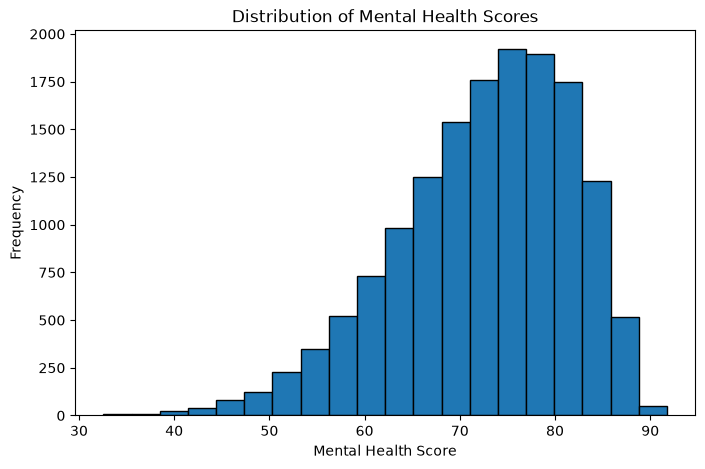

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df['Mental_Health_Score'], bins=20, edgecolor='black')
plt.title('Distribution of Mental Health Scores')
plt.xlabel('Mental Health Score')
plt.ylabel('Frequency')
plt.show()


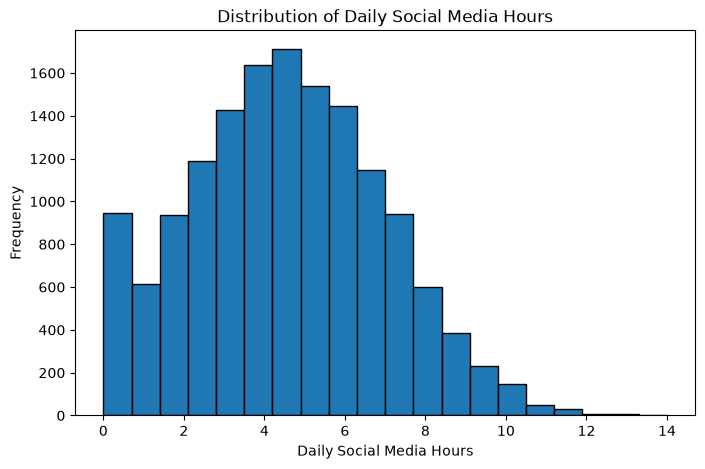

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df['Daily_Social_Media_Hours'], bins=20, edgecolor='black')
plt.title('Distribution of Daily Social Media Hours')
plt.xlabel('Daily Social Media Hours')
plt.ylabel('Frequency')
plt.show()


### Relationships with Mental Health Score

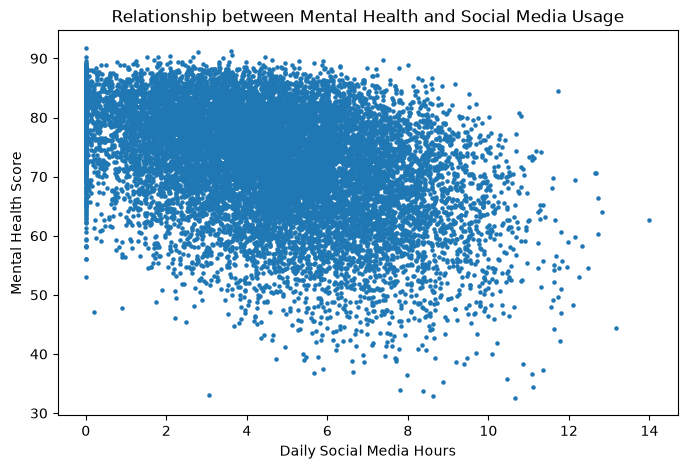

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['Daily_Social_Media_Hours'],
    df['Mental_Health_Score'],
    s=5
)
plt.title('Relationship between Mental Health and Social Media Usage')
plt.xlabel('Daily Social Media Hours')
plt.ylabel('Mental Health Score')
plt.show()


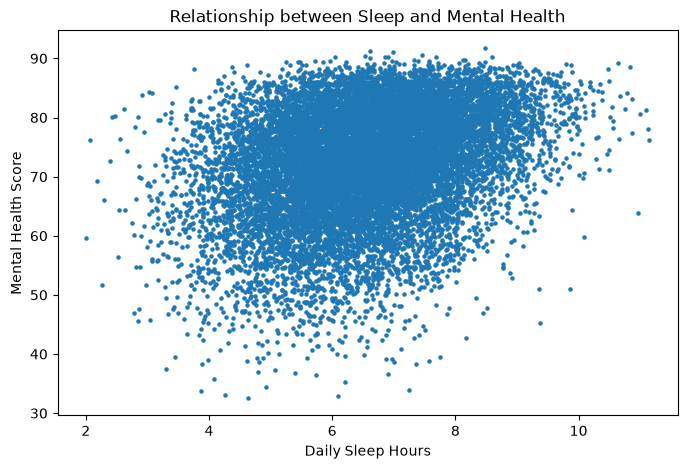

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['Sleep_Hours'],
    df['Mental_Health_Score'],
    s=5
)
plt.title('Relationship between Sleep and Mental Health')
plt.xlabel('Daily Sleep Hours')
plt.ylabel('Mental Health Score')
plt.show()


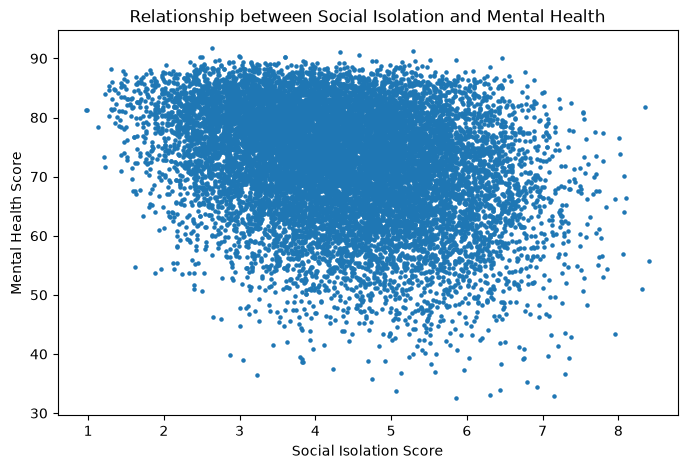

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['Social_Isolation_Score'],
    df['Mental_Health_Score'],
    s=5
)
plt.title('Relationship between Social Isolation and Mental Health')
plt.xlabel('Social Isolation Score')
plt.ylabel('Mental Health Score')
plt.show()


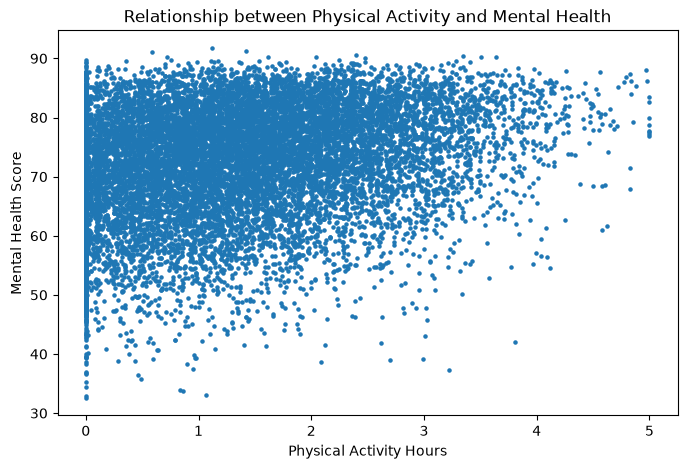

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['Physical_Activity_Hours'],
    df['Mental_Health_Score'],
    s=5
)
plt.title('Relationship between Physical Activity and Mental Health')
plt.xlabel('Physical Activity Hours')
plt.ylabel('Mental Health Score')
plt.show()


## 6. Correlation Analysis

Pearson correlation is used to measure the strength and direction of linear relationships between mental health score and selected behavioural variables.

A correlation coefficient ranges from **-1 to +1**:

- Values close to **-1** indicate a strong negative linear relationship.
- Values close to **+1** indicate a strong positive linear relationship.
- Values close to **0** indicate little or no linear relationship.


In [13]:
social_media_corr = df['Daily_Social_Media_Hours'].corr(df['Mental_Health_Score'])
sleep_corr = df['Sleep_Hours'].corr(df['Mental_Health_Score'])
social_isolation_corr = df['Social_Isolation_Score'].corr(df['Mental_Health_Score'])
physical_activity_corr = df['Physical_Activity_Hours'].corr(df['Mental_Health_Score'])

correlations = pd.Series({
    'Daily Social Media Hours': social_media_corr,
    'Sleep Hours': sleep_corr,
    'Social Isolation Score': social_isolation_corr,
    'Physical Activity Hours': physical_activity_corr
})

correlations


Daily Social Media Hours   -0.399802
Sleep Hours                 0.310587
Social Isolation Score     -0.291725
Physical Activity Hours     0.245876
dtype: float64

### Pearson Correlation: Social Media Use and Mental Health

In [14]:
correlation, p_value = pearsonr(
    df['Daily_Social_Media_Hours'],
    df['Mental_Health_Score']
)

print(f"Pearson correlation: {correlation:.3f}")
print(f"P-value: {p_value:.20e}")


Pearson correlation: -0.400
P-value: 0.00000000000000000000e+00


The Pearson correlation indicates a **moderate negative linear association** between daily social media use and mental health score.

The very small p-value provides strong statistical evidence against the null hypothesis of no linear association within this dataset.

However, statistical significance does **not** imply causation.


## 7. Comparing Higher and Lower Social Media Users

Students are divided into two groups using the mean daily social media usage as the threshold.

In [15]:
mean_social_media = df['Daily_Social_Media_Hours'].mean()

high_users = df[df['Daily_Social_Media_Hours'] > mean_social_media]
low_users = df[df['Daily_Social_Media_Hours'] <= mean_social_media]

print(f"Mean daily social media usage: {mean_social_media:.3f}")
print(f"High social media group size: {len(high_users)}")
print(f"Low social media group size: {len(low_users)}")


Mean daily social media usage: 4.537
High social media group size: 7414
Low social media group size: 7586


In [16]:
mean_mental_health_high = high_users['Mental_Health_Score'].mean()
mean_mental_health_low = low_users['Mental_Health_Score'].mean()

std_high = high_users['Mental_Health_Score'].std()
std_low = low_users['Mental_Health_Score'].std()

group_summary = pd.DataFrame({
    'Group': ['Higher social media use', 'Lower social media use'],
    'Mean Mental Health Score': [mean_mental_health_high, mean_mental_health_low],
    'Standard Deviation': [std_high, std_low],
    'Sample Size': [len(high_users), len(low_users)]
})

group_summary


,Group,Mean Mental Health Score,Standard Deviation,Sample Size
0,Higher social media use,69.503132,9.496112,7414
1,Lower social media use,75.454933,7.961679,7586


### Cohen's *d*

Cohen's *d* is used to quantify the standardised difference between the two group means.

In [17]:
pooled_std = np.sqrt(
    (high_users['Mental_Health_Score'].var() +
     low_users['Mental_Health_Score'].var()) / 2
)

cohens_d_value = (
    mean_mental_health_high - mean_mental_health_low
) / pooled_std

print(f"Cohen's d: {cohens_d_value:.3f}")


Cohen's d: -0.679


The negative value of Cohen's *d* reflects the fact that the higher-social-media group has a lower mean mental health score.

The magnitude indicates a **moderate-to-large standardised difference** between the groups.


## 8. Simple Linear Regression

A simple linear regression model is used to quantify the relationship between daily social media hours and mental health score.

In [18]:
linear_regression_result = linregress(
    df['Daily_Social_Media_Hours'],
    df['Mental_Health_Score']
)

print(f"Slope: {linear_regression_result.slope:.3f}")
print(f"Intercept: {linear_regression_result.intercept:.3f}")
print(f"r-value: {linear_regression_result.rvalue:.3f}")
print(f"p-value: {linear_regression_result.pvalue:.3e}")
print(f"Standard error: {linear_regression_result.stderr:.3f}")
print(f"Intercept standard error: {linear_regression_result.intercept_stderr:.3f}")
print(f"R-squared: {linear_regression_result.rvalue ** 2:.3f}")


Slope: -1.541
Intercept: 79.506
r-value: -0.400
p-value: 0.000e+00
Standard error: 0.029
Intercept standard error: 0.148
R-squared: 0.160


The regression slope is negative, indicating that higher daily social media use is associated with lower predicted mental health scores.

The slope can be interpreted as an estimated change of approximately **1.54 mental health score points for each additional hour of daily social media use**, within this dataset.

This remains an association rather than a causal estimate.


## 9. Multiple Linear Regression

A multiple linear regression model is used to investigate whether the relationship between social media use and mental health remains when additional behavioural variables are considered.

### Predictors

- Daily Social Media Hours
- Sleep Hours
- Social Isolation Score
- Physical Activity Hours

### Response Variable

- Mental Health Score


In [20]:
X = df[
    [
        'Daily_Social_Media_Hours',
        'Sleep_Hours',
        'Social_Isolation_Score',
        'Physical_Activity_Hours'
    ]
]

y = df['Mental_Health_Score']

X = sm.add_constant(X)

model = sm.OLS(y, X)
multiple_linear_regression_result = model.fit()

multiple_linear_regression_result.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     Mental_Health_Score   R-squared:                       0.235
Model:                             OLS   Adj. R-squared:                  0.235
Method:                  Least Squares   F-statistic:                     1154.
Date:                 Mon, 17 Aug 2026   Prob (F-statistic):               0.00
Time:                         11:34:47   Log-Likelihood:                -52632.
No. Observations:                15000   AIC:                         1.053e+05
Df Residuals:                    14995   BIC:                         1.053e+05
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       66.8474      0.562    118.989      0.000      65.746      67.949
Daily_Social_Media_Hours    -1.1535      0.031    -36.926      0.000      -1.215      -1.092
Sleep_Hours                  1.5008      0.056     26.988      0.000       1.392       1.610
Social_Isolation_Score      -0.2110      0.070     -3.012      0.003      -0.348      -0.074
Physical_Activity_Hours      1.5948      0.070     22.759      0.000       1.457       1.732
==============================================================================
Omnibus:                      711.227   Durbin-Watson:                   2.010
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              818.179
Skew:                          -0.550   Prob(JB):                    2.16e-178
Kurtosis:                       3.315   Cond. No.                         79.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The multiple regression model explains approximately **23.5% of the variance in mental health scores** based on the predictors included in the model.

The coefficient estimates should be interpreted as the expected change in mental health score associated with each predictor while holding the other predictors constant.


## 10. Regression Diagnostics

Regression diagnostics are used to assess whether important assumptions of the linear regression model appear reasonable.

In [21]:
predictions = multiple_linear_regression_result.predict(X)
residuals = y - predictions

residuals.head()


0    0.998827
1    0.596638
2   -6.170325
3    0.604513
4   -0.568487
dtype: float64

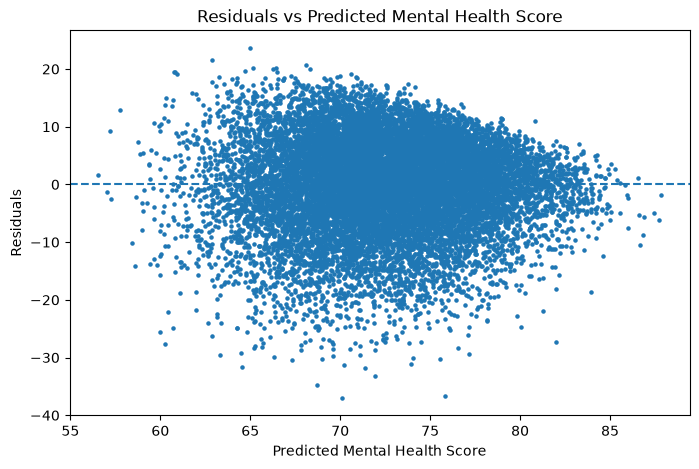

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(predictions, residuals, s=5)
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Mental Health Score')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Mental Health Score')
plt.show()


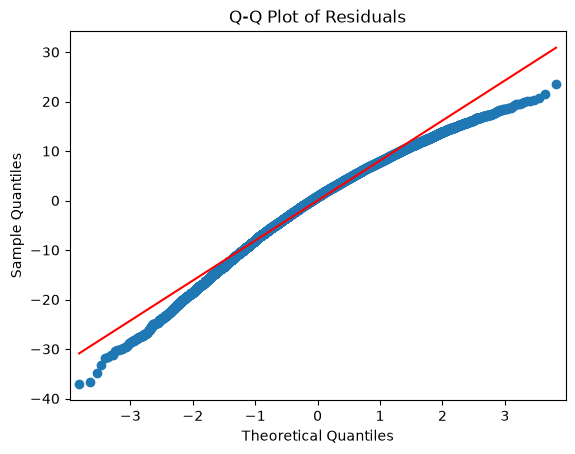

In [23]:
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()


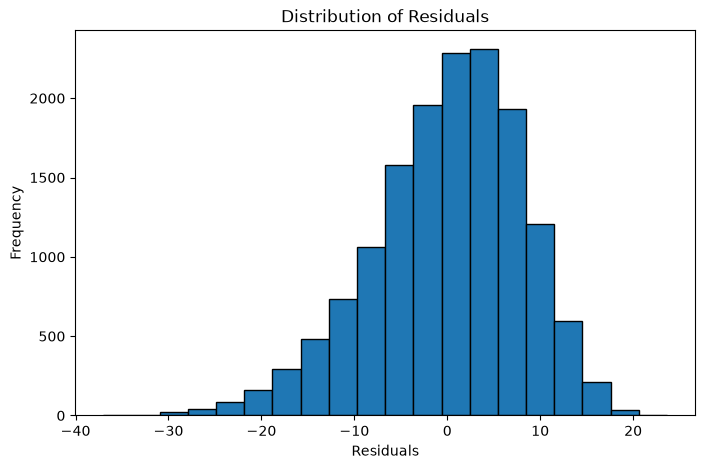

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=20, edgecolor='black')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()


### Breusch-Pagan Test

The Breusch-Pagan test is used to assess whether the residual variance is constant across observations.

- **H₀:** The residuals are homoscedastic.
- **H₁:** The residuals exhibit heteroscedasticity.

In [25]:
breusch_pagan_test = sms.het_breuschpagan(residuals, X)

print(f"LM Statistic: {breusch_pagan_test[0]:.3f}")
print(f"LM p-value: {breusch_pagan_test[1]:.3e}")


LM Statistic: 379.485
LM p-value: 7.521e-81


The Breusch-Pagan test provides evidence of **heteroscedasticity** in the regression residuals.

Because non-constant residual variance can affect conventional standard errors, robust HC3 standard errors are considered in the next section.


## 11. HC3 Robust Standard Errors

HC3 heteroscedasticity-robust standard errors provide an alternative basis for statistical inference when the constant-variance assumption is violated.

In [26]:
robust_model = multiple_linear_regression_result.get_robustcov_results(
    cov_type='HC3'
)

robust_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     Mental_Health_Score   R-squared:                       0.235
Model:                             OLS   Adj. R-squared:                  0.235
Method:                  Least Squares   F-statistic:                     1209.
Date:                 Mon, 17 Aug 2026   Prob (F-statistic):               0.00
Time:                         11:34:51   Log-Likelihood:                -52632.
No. Observations:                15000   AIC:                         1.053e+05
Df Residuals:                    14995   BIC:                         1.053e+05
Df Model:                            4                                         
Covariance Type:                   HC3                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       66.8474      0.566    118.106      0.000      65.738      67.957
Daily_Social_Media_Hours    -1.1535      0.031    -37.224      0.000      -1.214      -1.093
Sleep_Hours                  1.5008      0.055     27.266      0.000       1.393       1.609
Social_Isolation_Score      -0.2110      0.071     -2.968      0.003      -0.350      -0.072
Physical_Activity_Hours      1.5948      0.068     23.470      0.000       1.462       1.728
==============================================================================
Omnibus:                      711.227   Durbin-Watson:                   2.010
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              818.179
Skew:                          -0.550   Prob(JB):                    2.16e-178
Kurtosis:                       3.315   Cond. No.                         79.9
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

The HC3 model is used to assess whether the statistical conclusions are robust to the detected heteroscedasticity.

The coefficient estimates remain the same; the robust procedure adjusts the estimated standard errors and therefore the associated test statistics and confidence intervals.


## 12. Conclusion

The analysis identified a **moderate negative linear association** between daily social media usage and mental health score.

Students reporting greater daily social media use tended to have lower mental health scores. This relationship was statistically significant and remained relevant when sleep, social isolation, and physical activity were included in a multiple regression model.

The multiple regression model explained approximately **23.5% of the observed variation** in mental health scores.

Regression diagnostics indicated heteroscedasticity, so HC3 robust standard errors were considered when interpreting statistical inference.

Importantly, the results demonstrate **association rather than causation**. The dataset is synthetic and observational, and other factors may contribute to the relationships observed.


## 13. Next Steps

Possible extensions to this analysis could include:

- Testing nonlinear relationships.
- Investigating interactions between behavioural variables.
- Comparing alternative regression models.
- Examining additional predictors from the dataset.
- Exploring whether different modelling approaches produce similar conclusions.
